<a href="https://colab.research.google.com/github/mel-oezkan/computer-vision-proj-lab/blob/Jiaqi/ImageNet_process.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pytorch-lightning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 832.4/832.4 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 51.5 MB/s eta 0:00:00


In [1]:
import torch
import torchvision
from torch.utils.data import Dataset, DataLoader,Subset
from datasets import load_dataset



# Load the Dataset


In [2]:
import kagglehub

# Download latest version
path_1 = kagglehub.dataset_download("sautkin/imagenet1k0")

print("Path to first part of first 500 classes:", path_1)

# path_2 = kagglehub.dataset_download("sautkin/imagenet1k3")

# print("Path to second part of second 500 classes:", path_2)

path_val = kagglehub.dataset_download("sautkin/imagenet1kvalid")

print("Path to the validation data:", path_val)

100%|██████████| 11.9G/11.9G [02:13<00:00, 95.7MB/s]

Extracting files...


Path to first part of first 500 classes: /root/.cache/kagglehub/datasets/sautkin/imagenet1k0/versions/2


100%|██████████| 1.96G/1.96G [00:25<00:00, 82.2MB/s]

Extracting files...


Path to the validation data: /root/.cache/kagglehub/datasets/sautkin/imagenet1kvalid/versions/2


# Dataset

In [3]:
from torchvision import datasets,transforms
import os
import matplotlib.pyplot as plt
import numpy as np


transform=transforms.Compose([
    transforms.Resize((512,512)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
])

train_dataset=datasets.ImageFolder(root=path_1,transform=transform)
test_dataset=datasets.ImageFolder(root=path_val,transform=transform)





313614
00000
Total image number in class00000 : 655


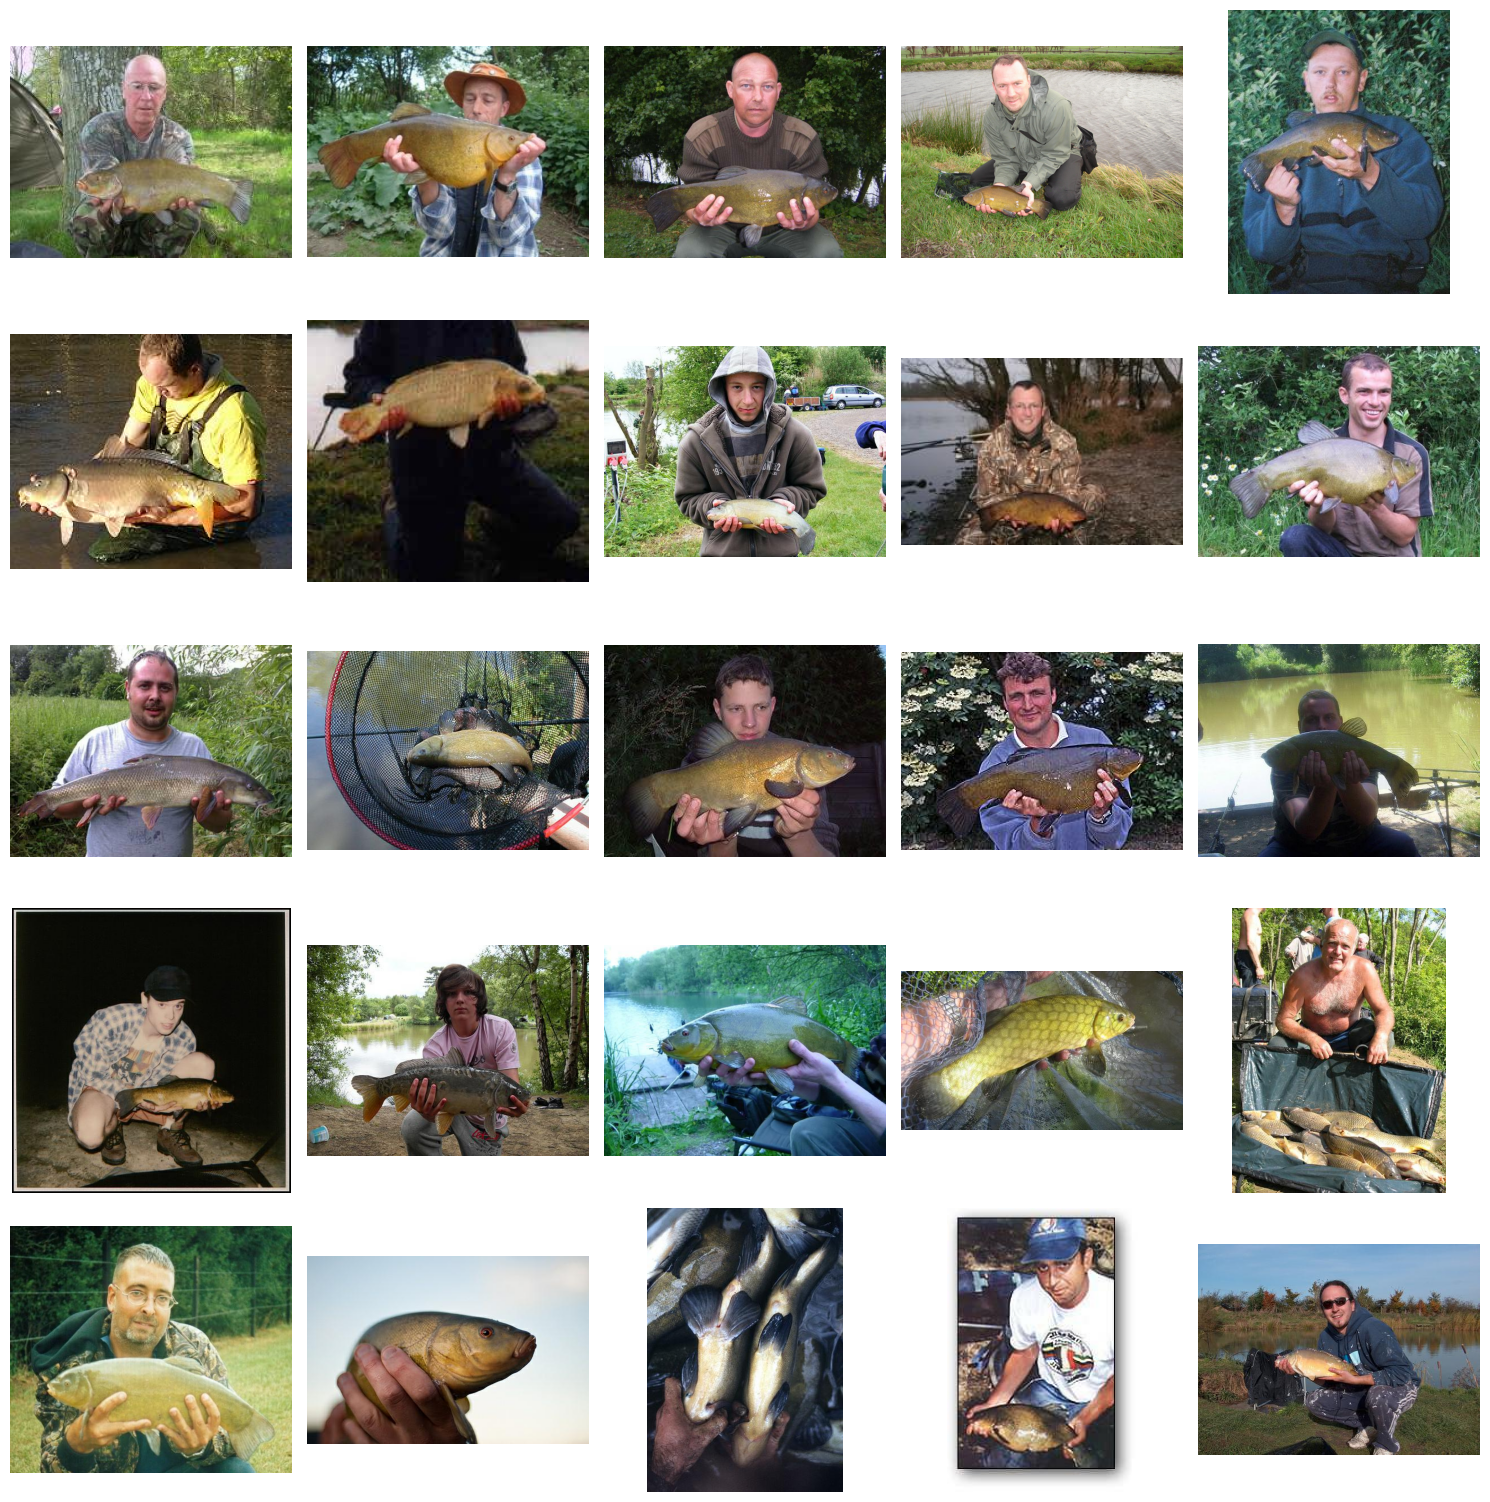

In [4]:
from PIL import Image

print(len(train_dataset))
#print(train_dataset.classes)


#print(len(train_dataset.classes[0]))
first_class_idx = list(train_dataset.class_to_idx.keys())[0]
print(first_class_idx)
first_class_path=os.path.join(path_1,first_class_idx)

image_files=[os.path.join(first_class_path, f) for f in os.listdir(first_class_path) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]

print(f'Total image number in class{first_class_idx} : {len(image_files)}')

max_images=min(25, len(image_files))

cols=5

rows=(max_images +cols-1)

plt.figure(figsize=(15,3*rows))
for i,img_path in enumerate(image_files[:max_images]):
    img=Image.open(img_path).convert("RGB")
    plt.subplot(rows,cols,i+1)
    plt.imshow(img)
    plt.axis("off")
plt.tight_layout()
plt.show()


# img1,label1=train_dataset[3]


# image1=img1.permute(1,2,0).cpu().numpy()



# img3,label3=test_dataset[6]
# image3=img3.permute(1,2,0).cpu().numpy()

# plt.figure()

# plt.subplot(121)
# plt.imshow(image1)
# plt.axis("off")

# plt.subplot(122)
# plt.imshow(image3)

# plt.axis("off")

# plt.show()



# DataLoader

In [5]:
train_dataloader=DataLoader(train_dataset,batch_size=32,shuffle=True)
#valid_dataloader=DataLoader(valid_dataset,batch_size=32,shuffle=True)
test_dataloader=DataLoader(test_dataset,batch_size=32)

imags,labels=next(iter(test_dataloader))

print(imags.shape)

torch.Size([32, 3, 512, 512])


In [6]:
import random
all_classes=list(train_dataset.class_to_idx.keys())


# Load KL-VAE

In [7]:
!pip install diffusers transformers accelerate safetensors


# encode random 10 classes

In [9]:
torch.cuda.empty_cache()
!nvidia-smi

Tue Nov  4 09:21:36 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   48C    P8             12W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
selected_classes=random.sample(all_classes,10)
selected_indices=[train_dataset.class_to_idx[c] for c in selected_classes]
print("selected classes:")
for c in selected_classes:
    print(f" {c}")

subset_indices= [ i for i,(_,label) in enumerate(train_dataset.samples) if label in selected_indices]
subset_dataset=Subset(dataset=train_dataset,indices=subset_indices)
subset_loader=DataLoader(dataset=subset_dataset,batch_size=16,shuffle=False)

# imges,labels= next(iter(subset_loader))
# print(imges.shape)

In [10]:
from diffusers import AutoencoderKL
from PIL import Image
from tqdm import tqdm
import glob



device= torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device:{device}")

vae=AutoencoderKL.from_pretrained(
    "stabilityai/stable-diffusion-2-1-base",
    subfolder="vae",
    torch_dtype=torch.float16
).to(device).eval()

# transform=transforms.Compose([
#     transforms.Resize((512,512)),
#     transforms.ToTensor(),
#     transforms.Normalize([0.5], [0.5]),
# ])


# test_img_path=os.path.join(os.getcwd(),"dog_3.jpg")
# img=Image.open(test_img_path).convert("RGB")
# x=transform(img).unsqueeze(0).float().to(device)

# posterior=vae.encode(x=x).latent_dist
# z=posterior.sample()

# print(f'latent code shape:{z.shape}')

# plt.figure(figsize=(6,10))
# img_z=z.squeeze(0).permute(1,2,0).detach().cpu().numpy()
# plt.imshow(img_z)
# plt.show()


latent_codes=[]
labels=[]
save_dir=os.path.join(os.getcwd(),"latent_batches_in_10_classes")
if not os.path.exists(save_dir):
    os.makedirs(save_dir,exist_ok=True)

with torch.no_grad():
    for i,(imgs,lbs) in enumerate(tqdm(subset_loader,desc="Encoding 10 classes")):
        imgs=imgs.to(device=device,
                     dtype=torch.float16
                     )
        posterior=vae.encode(imgs).latent_dist
        z=posterior.sample().cpu().float() #(N,4,64,64)
        #print(f"shape of z: {z.shape}")
        z_flat=z.flatten(start_dim=1).numpy() #(N,4*64*64)
        # latent_codes.append(z_flat.cpu().numpy())
        # labels.extend(lbs.numpy())
        np.savez_compressed(file=f"{save_dir}/batch_{i:04d}.npz",latent=z_flat,labels=lbs.numpy())

        del imgs, posterior, z
        torch.cuda.empty_cache()


files=sorted(glob.glob(f"{save_dir}/batch_*.npz"))

for f in files:
    data=np.load(f)
    latent_codes.append(data["latent"])
    labels.append(data["labels"])

latent_codes=np.concatenate(latent_codes,axis=0)
labels=np.concatenate(labels,axis=0)
print(f'latent_codes shape: {latent_codes.shape}')





Using device:cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/553 [00:00<?, ?B/s]

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Encoding 10 classes: 100%|██████████| 392/392 [07:56<00:00,  1.21s/it]


latent_codes shape: (6257, 16384)


In [11]:
#torch.cuda.empty_cache()
!nvidia-smi

Tue Nov  4 09:30:09 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   71C    P0             32W /   72W |    1431MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## TSNE visualize

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


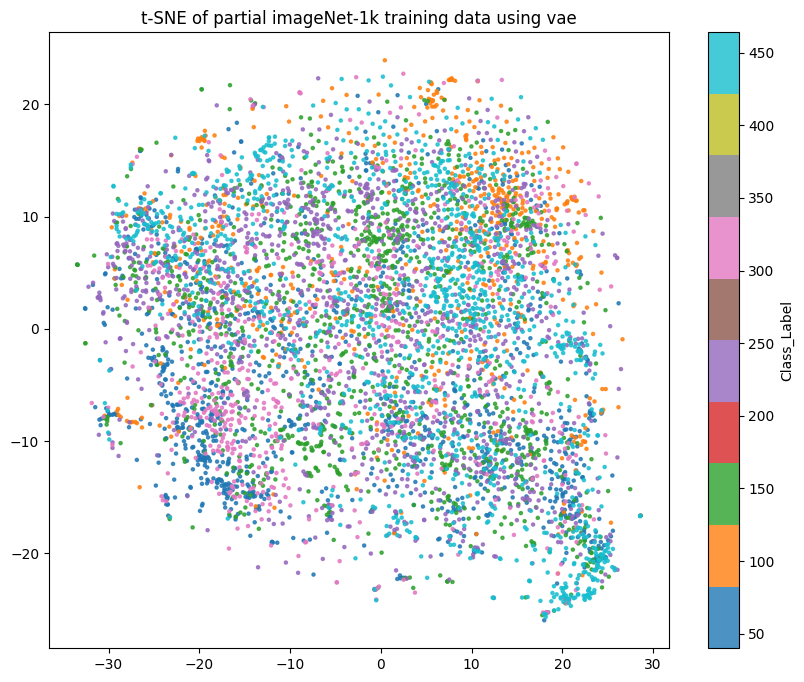

In [12]:
from sklearn.manifold import TSNE
tsne=TSNE(n_components=2,perplexity=30,n_iter=1000)
z_2d=tsne.fit_transform(latent_codes)

#visualize

plt.figure(figsize=(10,8))
scatter=plt.scatter(x=z_2d[:,0],y=z_2d[:,1],c=labels, cmap="tab10",s=5,alpha=0.8)
plt.colorbar(scatter, label="Class_Label")
plt.title(f"t-SNE of partial imageNet-1k training data using vae")
plt.show()

In [15]:
import plotly.express as px

tsne_3d=TSNE(n_components=3,perplexity=30,learning_rate=20)
z_3d=tsne_3d.fit_transform(latent_codes)

fig = px.scatter_3d(x=z_3d[:, 0], y=z_3d[:, 1], z=z_3d[:, 2], color=labels, opacity=0.8)
fig.show()

# encode one class

In [8]:
torch.cuda.empty_cache()
!nvidia-smi

Tue Nov  4 16:28:15 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [9]:
selected_class=random.choice(all_classes)
selected_label=train_dataset.class_to_idx[selected_class]
print(f'the chosen class is: {selected_class}, label={selected_label}')

selected_indices= [ i for i,(_,label) in enumerate(train_dataset.samples) if label ==selected_label]

selected_dataset=Subset(train_dataset,selected_indices)
selected_loader=DataLoader(selected_dataset)

print(f'image number of selected dataset is:{len(selected_dataset)}')


the chosen class is: 00094, label=94
image number of selected dataset is:629


In [12]:
from diffusers import AutoencoderKL
from PIL import Image
from tqdm import tqdm
import glob



device= torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device:{device}")

vae=AutoencoderKL.from_pretrained(
    "stabilityai/stable-diffusion-2-1-base",
    subfolder="vae",
    torch_dtype=torch.float16
).to(device).eval()

latent_codes=[]

save_selected_dir=os.path.join(os.getcwd(),"latent_batches_in_random_classes")
if not os.path.exists(save_selected_dir):
    os.makedirs(save_selected_dir,exist_ok=True)

with torch.no_grad():
    for i, (imgs,_) in enumerate(tqdm(selected_loader)):
        imgs=imgs.to(device=device,dtype=torch.float16)
        posterior=vae.encode(imgs).latent_dist
        z=posterior.sample().cpu().float()
        z_flat=z.flatten(start_dim=1).numpy()

        np.savez_compressed(file=f"{save_selected_dir}/batch_{i:04d}.npz",latent=z_flat)

        del imgs, posterior, z
        torch.cuda.empty_cache()

files=sorted(glob.glob(f"{save_selected_dir}/batch_*.npz"))

for f in files:
    data=np.load(f)
    latent_codes.append(data["latent"])
latent_codes=np.concatenate(latent_codes,axis=0)
print(f'latent_codes shape: {latent_codes.shape}')






Using device:cuda


100%|██████████| 629/629 [01:17<00:00,  8.17it/s]


latent_codes shape: (629, 16384)


## TSNE visualize

In [ ]:
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, verbose=1)
z_2d = tsne.fit_transform(latent_codes)

**color according to the distance from the center**

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 629 samples in 0.004s...
[t-SNE] Computed neighbors for 629 samples in 0.455s...
[t-SNE] Computed conditional probabilities for sample 629 / 629
[t-SNE] Mean sigma: 164.927824
[t-SNE] KL divergence after 250 iterations with early exaggeration: 72.316513
[t-SNE] KL divergence after 1000 iterations: 1.376143


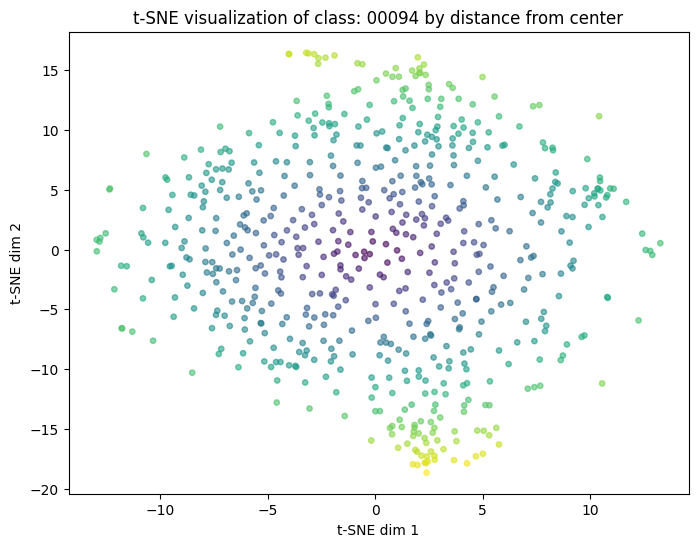

In [14]:

center=z_2d.mean(axis=0)
distances=np.linalg.norm(z_2d-center,axis=1)



plt.figure(figsize=(8, 6))
plt.scatter(z_2d[:, 0], z_2d[:, 1], s=15, c=distances,cmap='viridis', alpha=0.6)
plt.title(f"class: {selected_class} colored by distance from center")
plt.xlabel("dim 1")
plt.ylabel("dim 2")
plt.show()


**color according to the local density**

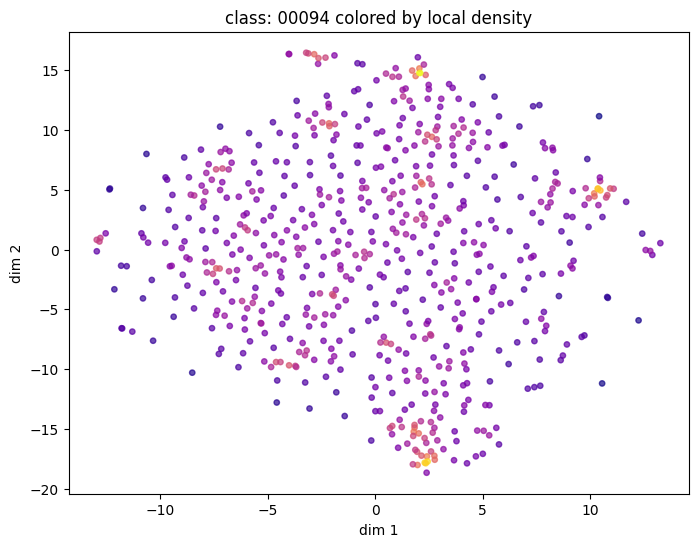

In [15]:
from sklearn.neighbors import NearestNeighbors

neighbors=NearestNeighbors(n_neighbors=5).fit(z_2d)
distances, _=neighbors.kneighbors(z_2d)

local_density= 1/ (distances[:,1:].mean(axis=1) +1e-5)

plt.figure(figsize=(8, 6))
plt.scatter(z_2d[:, 0], z_2d[:, 1], s=15, c=local_density,cmap='plasma', alpha=0.7)
plt.title(f"class: {selected_class} colored by local density")
plt.xlabel("dim 1")
plt.ylabel("dim 2")
plt.show()

**color according to axis distance**

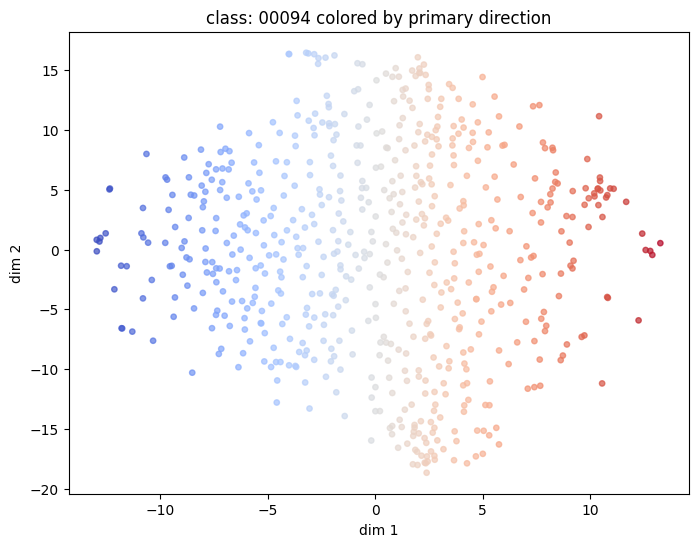

In [16]:
plt.figure(figsize=(8, 6))
plt.scatter(z_2d[:, 0], z_2d[:, 1], c=z_2d[:,0],s=15,cmap='coolwarm', alpha=0.7)
plt.title(f"class: {selected_class} colored by primary direction")
plt.xlabel("dim 1")
plt.ylabel("dim 2")
plt.show()

# Interpolation

In [8]:
# pick 2 images in selected class
selected_class=random.choice(all_classes)
selected_label=train_dataset.class_to_idx[selected_class]
print(f'the chosen class is: {selected_class}, label={selected_label}')

selected_indices= [ i for i,(_,label) in enumerate(train_dataset.samples) if label ==selected_label]

selected_dataset=Subset(train_dataset,selected_indices)
selected_loader=DataLoader(selected_dataset)

all_imgs=[]
for imgs,_ in selected_loader:
    all_imgs.append(imgs)
all_imgs=torch.cat(all_imgs,dim=0)

idx1,idx2=random.sample(range(len(all_imgs)),2)
img1,img2= all_imgs[idx1:idx1+1],all_imgs[idx2:idx2+1]
print(f'selected images indices: {idx1} and {idx2}')


the chosen class is: 00288, label=288
selected images indices: 231 and 637


In [9]:
torch.cuda.empty_cache()
!nvidia-smi

Tue Nov  4 19:20:23 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [10]:
def linear_interpolation(z1:torch.Tensor,z2:torch.Tensor,alphas):
    return [(1 - a) * z1 + a * z2 for a in alphas]


In [11]:
def spherical_interpolation(z1:torch.Tensor,z2:torch.Tensor,alphas):
    def calc(t,x1,x2):
        x1_norm=x1 / torch.norm(x1)
        x2_norm=x2 / torch.norm(x2)

        dot=torch.sum(x1_norm * x2_norm)

        theta= torch.acos(dot)
        sin_theta=torch.sin(theta)
        if sin_theta==0:
            return (1-t) * x1 + t * x2
        return (torch.sin((1- t) *theta)/ sin_theta) * x1 + (torch.sin(t * theta) / sin_theta) *x2

    return [ calc(a, z1, z2) for a in alphas]

Using device:cuda


spherical interpolation: 100%|██████████| 6/6 [00:01<00:00,  5.42it/s]


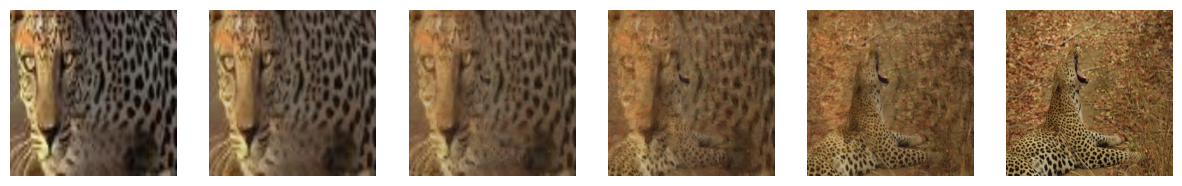

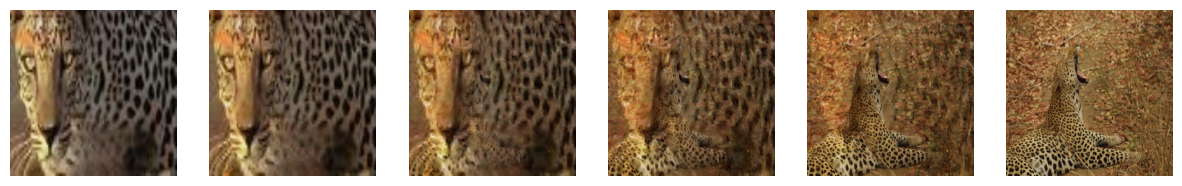

In [16]:
from diffusers import AutoencoderKL
from PIL import Image
from tqdm import tqdm
import glob



device= torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device:{device}")

vae=AutoencoderKL.from_pretrained(
    "stabilityai/stable-diffusion-2-1-base",
    subfolder="vae",
    torch_dtype=torch.float16
).to(device).eval()

img1,img2=img1.to(device=device, dtype=torch.float16),img2.to(device=device, dtype=torch.float16)


with torch.no_grad():
    z1=vae.encode(img1).latent_dist.sample()
    z2=vae.encode(img2).latent_dist.sample()

#interpolation
steps=6
alphas=np.linspace(0,1,steps)

z_linear_inter= linear_interpolation(z1,z2,alphas)

z_spherical_inter= spherical_interpolation(z1,z2,alphas)

#decode

decoded_imgs_linear=[]
decoded_imgs_spherical=[]


with torch.no_grad():
    for z in tqdm(z_linear_inter,desc="linear interpolation"):
        img_recover=vae.decode(z).sample
        decoded_imgs_linear.append(img_recover)

    for z in tqdm(z_spherical_inter,desc="spherical interpolation"):
        img_recover=vae.decode(z).sample
        decoded_imgs_spherical.append(img_recover)

#visualize
fig1, axes1 = plt.subplots(1,steps,figsize=(15,3))

for i,img in enumerate(decoded_imgs_linear):
    img_np=img.detach().cpu().squeeze(0)

    img_np=(img_np *0.5 +0.5).clip(0,1)

    img_np=img_np.permute(1,2,0).numpy().astype("float32")
    axes1[i].imshow(img_np)

    axes1[i].axis("off")


fig2, axes2 = plt.subplots(1,steps,figsize=(15,3))

for i,img in enumerate(decoded_imgs_spherical):
    img_np=img.detach().cpu().squeeze(0)

    img_np=(img_np *0.5 +0.5).clip(0,1)

    img_np=img_np.permute(1,2,0).numpy().astype("float32")
    axes2[i].imshow(img_np)
    axes2[i].axis("off")

plt.show()





